In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #51daca; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #04335a">Stokes Equations </h3>
</div>

- Stokes flow, also named creeping flow or creeping motion, is a type of fluid flow where advective inertial <br>
forces are small compared with viscous forces. The Reynolds number is low, i.e. $\displaystyle \mathrm {Re} \ll 1$. <br>
This is a typical situation in flows where the fluid velocities are very slow, the viscosities are very large, <br>
or the length-scales of the flow are very small. Creeping flow was first studied to understand lubrication. <br>
In nature, this type of flow occurs in the swimming of microorganisms and sperm. In technology, it occurs <br>
in paint, MEMS devices, and in the flow of viscous polymers generally.

$$
\begin{cases}
-\nu \Delta u + \nabla p = 0
& \text{in } \Omega, \\[0.5em]

\nabla \cdot u = 0
& \text{in } \Omega, \\[0.5em]

u = g
& \text{on } \Gamma_D, \\[0.5em]

-p\,n + \nu (\nabla u)n = h
& \text{on } \Gamma_N.
\end{cases}
$$

- Find $(u,p) \in X \times Q$ such that:

$$
\begin{cases}
\displaystyle
\int_{\Omega} \nu \nabla u : \nabla v \, d\Omega
-
\int_{\Omega} p \, (\nabla \cdot v)\, d\Omega
=
\int_{\Gamma_N} h \cdot v \, d\Gamma
-
\int_{\Omega} \nu \nabla r_g : \nabla v \, d\Omega,
& \forall v \in X,
\\[1.2em]

\displaystyle
-\int_{\Omega} q \, (\nabla \cdot u)\, d\Omega
=
\int_{\Omega} q \, (\nabla \cdot r_g)\, d\Omega,
& \forall q \in Q.
\end{cases}
$$

<div align="center">
Where:

$$
\nabla u : \nabla v
=
\sum_{i,j}
\frac{\partial u_i}{\partial x_j}
\frac{\partial v_i}{\partial x_j}
$$

 - or if we use a simplified notation:

$$
\begin{array}{cc}
\displaystyle
d(v,w)
=
\int_{\Omega}
\nu \, \nabla v : \nabla w
\, d\Omega
&
\displaystyle
b(v,q)
=
-
\int_{\Omega}
q \, (\nabla \cdot v)
\, d\Omega
\\[1.5em]

\displaystyle
f_1(w)
=
\int_{\Gamma_N}
h \cdot w
\, d\Gamma
-
d(r_g,w)
&
\displaystyle
f_2(q)
=
-
b(r_g,q)
\end{array}
$$

- Find $(u,p)\in X \times Q$ such that:

$$
\begin{cases}
d(u,v) + b(v,p)
=
f_1(v),
& \forall v \in X,
\\[1em]

b(u,q)
=
f_2(q),
& \forall q \in Q.
\end{cases}
$$

<br>
<br>
<br>

---

$$
\left[
\begin{array}{ccc}
\mathbb{A} & 0 & \mathbb{B}_x^T \\
0 & \mathbb{A} & \mathbb{B}_y^T \\
\mathbb{B}_x & \mathbb{B}_y & 0
\end{array}

\right]
\begin{bmatrix}
\mathbf{U}_x \\
\mathbf{U}_y \\
\mathbf{P}
\end{bmatrix}
=
\begin{bmatrix}
\mathbf{F}_x \\
\mathbf{F}_y \\
\mathbf{0}
\end{bmatrix}
$$

$$
\\[30pt]
\mathbb{A} \in \mathbf{R}^{N_u \times N_u} \\[13pt]
\mathbb{B}_x \in \mathbf{R}^{N_p \times N_u} \\[13pt]
\mathbb{B}_x^T \in \mathbf{R}^{N_u \times N_p}
$$

---
Imports:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from Utilities.fem_poisson import *
from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import *

<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0;  color: #11116e">Mesh </h3>
</div>

We begin with the mesh construction and refinement:

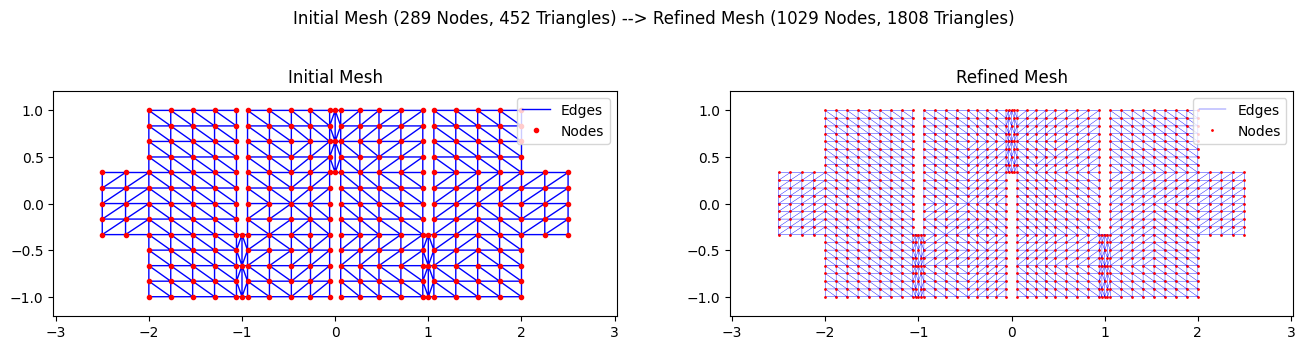

In [3]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_mesh_data.npz', num_of_refinements=1, 
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

In [4]:
mesh_df(p_coarse, e_coarse, t_coarse, first_n_entries=13)

p is of shape: (1029, 2)
e is of shape: (2836, 3)
t is of shape: (1808, 7)


In [5]:
mesh_df(p_fine, e_fine, t_fine, first_n_entries=13)

p is of shape: (3865, 2)
e is of shape: (11096, 3)
t is of shape: (7232, 7)


---


<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #11116e">The &#120120; matrix</h3> 
</div>


$$
\begin{aligned}
A^{loc}_{ij} &= \int_T \nu (\nabla \hat{\phi_j})^T \cdot J_T^{-1}J_T^{-T} \cdot \nabla \hat{\phi_i} |J_T| d\xi_1 d\xi_2 \\
&= \frac{\nu}{2|J_T|}\cdot  (\nabla \hat{\phi_j})^T \mathbb{Q} \nabla \hat{\phi_i}
\end{aligned}
$$

In [6]:
def calculate_velocity_A(p, t, kinematic_viscosity):
    """
    This is a matrix for the first integral in the Stokes Equations - The Stiffness Matrix A
    """

    Np = p.shape[0]
    Nt = t.shape[0]

    # we calculate all jacobians simultaneously           J = |x_2 - x_1   y_2 - y_1|
    #                                                         |x_3 - x_1   y_3 - y_1|

    jacobian = np.zeros(shape=(Nt, 2, 2))
    jacobian[:, 0, :] = p[t[:, 1]] - p[t[:, 0]] 
    jacobian[:, 1, :] = p[t[:, 2]] - p[t[:, 0]] 

    det_J = jacobian[:, 0, 0] * jacobian[:, 1, 1] - jacobian[:, 0, 1] * jacobian[:, 1, 0]

    # Cofactor multiplication matrix Q:                   Q = |(y_3 - y_1)^2 + (x_3 - x_1)^2                   (y_1 - y_2)(y_3 - y_1) + (x_2 - x_1)(x1 - x_3)|
    #                                                         |(y_1 - y_2)(y_3 - y_1) + (x_2 - x_1)(x1 - x_3)  (y_2 - y_1)^2 + (x_2 - x_1)^2                 |
    #
    #                                                     Q = Cof(J).T @ Cof(J)

    q11 = jacobian[:, 1, 1]**2 + jacobian[:, 1, 0]**2
    q12 = -(jacobian[:, 0, 1] * jacobian[:, 1, 1] + jacobian[:, 0, 0] * jacobian[:, 1, 0])
    q22 = jacobian[:, 0, 1]**2 + jacobian[:, 0, 0]**2

    Q_mat = np.zeros_like(jacobian)
    Q_mat[:, 0, 0] = q11
    Q_mat[:, 1, 0], Q_mat[:, 0, 1] = q12, q12
    Q_mat[:, 1, 1] = q22
    
    test_function_derivatives = np.array([[-1, -1],   # ф1 = 1 - s_1 - s_2
                                          [1, 0],     # ф2 = s_1
                                          [0, 1]])    # ф3 = s_2


    # We can now construct a local matrix A for each triangle:
    
    A_local = np.zeros(shape=(Nt, 3, 3))
    for i in range(3):
        for j in range(i, 3):

            grad_i = test_function_derivatives[i]
            grad_j = test_function_derivatives[j]

            val = np.einsum(
                'i, nij, j->n', 
                grad_j,
                Q_mat,
                grad_i
            )

            val *= kinematic_viscosity / (2 * det_J)

            A_local[:, i, j] = val
            A_local[:, j, i] = val

    # INVESTIGATE:
    # A_local = np.einsum('mi,tkj,nj->tmn', test_function_derivatives, Q_mat, test_function_derivatives)
    # A_local *= (kinematic_viscosity / (2.0 * np.abs(det_J)))[:, None, None]

    rowidx = np.einsum("ni,j->nij", t[:,0:3], [1,1,1])
    colidx = np.einsum("nj,i->nij", t[:,0:3], [1,1,1])
    
    # Return corresponding csc_matrix
    return sparse.csc_matrix((np.ravel(A_local),(np.ravel(rowidx),np.ravel(colidx))),shape=(Np,Np))

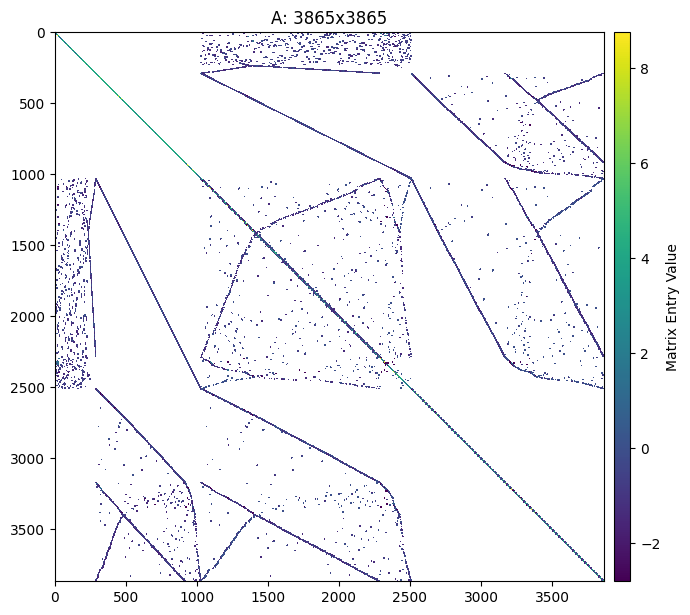

In [7]:
A = calculate_velocity_A(p_fine, t_fine, 1)
Stokes_matrix_structure(A, 'A', (7,7))

---

<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #11116e">&#120121;<sub>x</sub> and &#120121;<sub>y</sub> matrices</h3>
</div>


$P_1\text{-iso-}P_1$ Mesh is used for the Stokes Equations in this demonstration.

$$
\begin{aligned}
B^x_{ij} = -\int_{\Omega}\psi _j \frac{\partial \phi _i}{\partial x} d \Omega \quad & \quad B^y_{ij} = -\int_{\Omega}\psi _j \frac{\partial \phi _i}{\partial y} d \Omega
\end{aligned}
$$

$$
\left[
    \begin{array}{c}
    \frac{\partial \phi _i}{\partial x}\\[15pt]
    \frac{\partial \phi _i}{\partial y}
    \end{array}  
\right]
= |J_T|^{-1}
\left[
    \begin{array}{c}
    \quad (y_3 - y_1)\frac{\partial \hat{\phi} _i}{\partial \xi _1} - (y_2 - y_1)\frac{\partial \hat{\phi} _i}{\partial \xi _2}\\[15pt]
    \space-(x_3 - x_1)\frac{\partial \hat{\phi} _i}{\partial \xi _1} + (x_2 - x_1)\frac{\partial \hat{\phi} _i}{\partial \xi _2}
    \end{array}  
\right]
$$

$$
\begin{aligned}
(\mathbb{B}^{loc}_x)_{ij} = \frac{1}{6} \Big((y_2 - y_1)\frac{\partial \hat{\phi} _i}{\partial \xi _2} - (y_3 - y_1)\frac{\partial \hat{\phi} _i}{\partial \xi _1} \Big) \quad & \quad (\mathbb{B}^{loc}_y)_{ij} = \frac{1}{6} \Big((x_3 - x_1)\frac{\partial \hat{\phi} _i}{\partial \xi _1} - (x_2 - x_1)\frac{\partial \hat{\phi} _i}{\partial \xi _2}\Big) 
\end{aligned}
$$

In [8]:
def calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse):
    """Calculates the pressure matrices Bx, By"""

    Np_fine = p_fine.shape[0]
    Nt_fine = t_fine.shape[0]

    Np_coarse = p_coarse.shape[0]
    Nt_coarse = t_coarse.shape[0]

    jacobian = np.zeros(shape=(Nt_fine, 2, 2))
    jacobian[:, 0, :] = p_fine[t_fine[:, 1]] - p_fine[t_fine[:, 0]] 
    jacobian[:, 1, :] = p_fine[t_fine[:, 2]] - p_fine[t_fine[:, 0]] 

    test_function_derivatives = np.array([[-1, -1],   # ф1 = 1 - s_1 - s_2
                                          [1, 0],     # ф2 = s_1
                                          [0, 1]])    # ф3 = s_2
    
    # We can now construct local matrices Bx, By for each triangle:

    Bx_local = np.zeros(shape=(Nt_fine, 3, 3))
    By_local = np.zeros(shape=(Nt_fine, 3, 3))

    # for i in [0, 1, 2]:
    #     for j in [0, 1, 2]:
    #         Bx_local[:, i, j] = 1/6 * (  jacobian[:, 0, 1] * test_function_derivatives[i, 1]       
    #                                    - jacobian[:, 1, 1] * test_function_derivatives[i, 0])

    #         By_local[:, i, j] = 1/6 * (  jacobian[:, 1, 0] * test_function_derivatives[i, 0] 
    #                                    - jacobian[:, 0, 0] * test_function_derivatives[i, 1])
            
    # print(Bx_local[0],'\n')
    # print(By_local[0],'\n')
            
    Bx_vals = 1/6 * (  jacobian[:, 0, 1, None] * test_function_derivatives[:, 1]       
                     - jacobian[:, 1, 1, None] * test_function_derivatives[:, 0])
    
    By_vals = 1/6 * (  jacobian[:, 1, 0, None] * test_function_derivatives[:, 0] 
                     - jacobian[:, 0, 0, None] * test_function_derivatives[:, 1])
    
    Bx_local = np.repeat(Bx_vals[:, :, None], 3, axis=2)
    By_local = np.repeat(By_vals[:, :, None], 3, axis=2)

    # print(Bx_local[0], '\n !!!\n ', 
    #       jacobian[:, 1, 0, None][:5], '\n !!!\n ', 
    #       jacobian[:, 1, 0][:5], '\n !!!\n ',
    #       test_function_derivatives[:, 1])

    # We now adress the global matrix problem for Bx and By:
    
    # INVESTIGATE:
    fine_to_coarse_idx = np.repeat(np.arange(Nt_coarse), 4)[:Nt_fine]
    colidx = np.tile(t_fine[:, :3, None], (1, 1, 3)).ravel()
    parent_coarse_nodes = t_coarse[fine_to_coarse_idx, :3]
    rowidx = np.tile(parent_coarse_nodes[:, None, :], (1, 3, 1)).ravel()
    
    B_x = sparse.csc_matrix((np.ravel(Bx_local),
                            (np.ravel(rowidx), np.ravel(colidx))),
                            shape=(Np_coarse, Np_fine))
    
    B_y = sparse.csc_matrix((np.ravel(By_local),
                            (np.ravel(rowidx), np.ravel(colidx))),
                            shape=(Np_coarse, Np_fine))

    return B_x, B_y

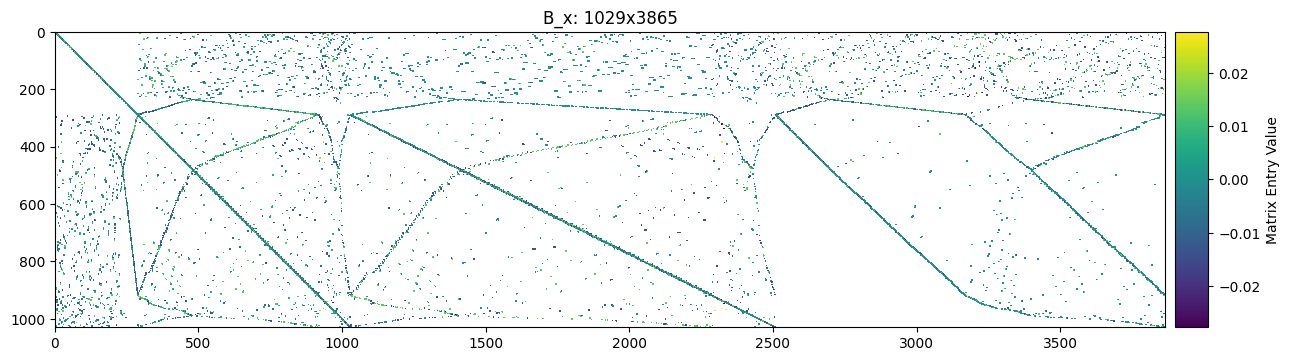

In [10]:
B_x, B_y = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
Stokes_matrix_structure(B_x, 'B_x')

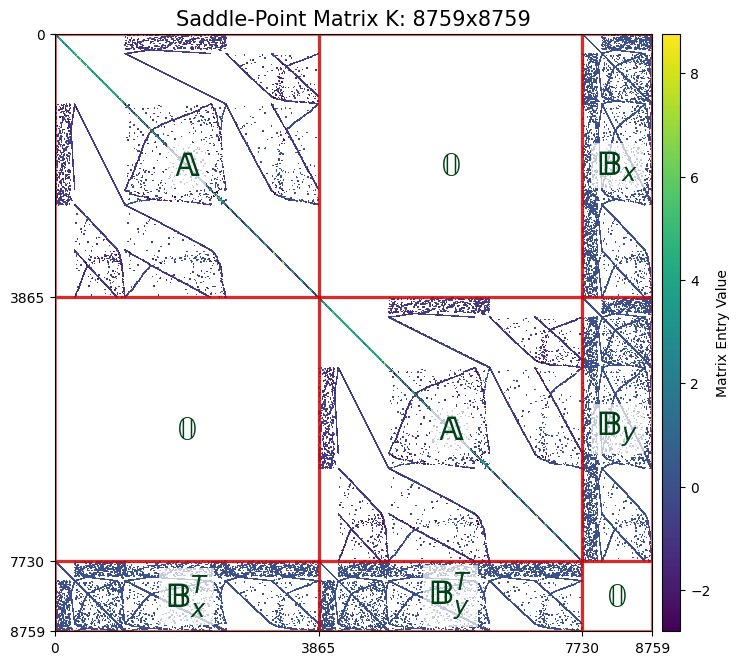

In [ ]:
K = calculate_Saddle_point_K(A, B_x, B_y)
K_matrix_structure(K, A.shape[0], B_x.shape[0], (7.5,7.5))

Solving system...
||div|| = 8.617529819523251e-06
max div = 8.617529819523251e-06


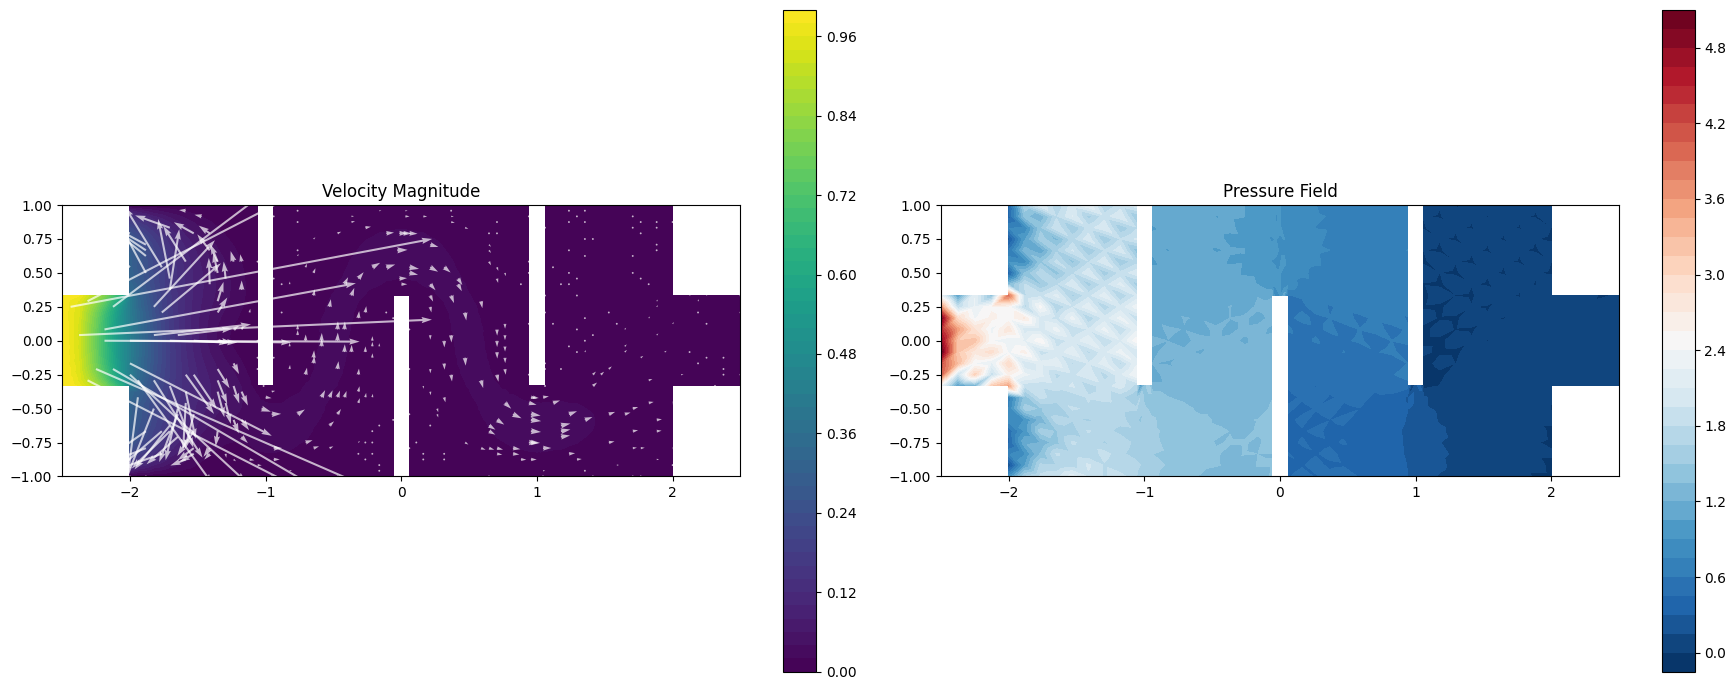

In [ ]:
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# =====================================================================================
# STOKES SOLVER
# =====================================================================================

def solve_stokes_final_v4(p_fine, t_fine,
                          p_coarse, t_coarse,
                          A, Bx, By):

    Nv = p_fine.shape[0]
    Np = p_coarse.shape[0]

    # =================================================================================
    # GLOBAL SYSTEM
    # =================================================================================

    #!!! changed
    Zero_vv = sparse.csc_matrix((Nv, Nv))
    Zero_pp = sparse.csc_matrix((Np, Np))

    #!!! changed
    K = sparse.bmat([
        [A,        Zero_vv, Bx.T],
        [Zero_vv,  A,       By.T],
        [Bx,       By,      Zero_pp]
    ], format='lil')

    F = np.zeros(2 * Nv + Np)

    # =================================================================================
    # GEOMETRY
    # =================================================================================

    eps = 1e-2

    xmin = p_fine[:,0].min()
    xmax = p_fine[:,0].max()

    ymin = p_fine[:,1].min()
    ymax = p_fine[:,1].max()

    # =================================================================================
    # INLET
    # =================================================================================

    #!!! changed
    is_inlet = (
        np.abs(p_fine[:,0] - xmin) < eps
    )

    inlet_idx = np.where(is_inlet)[0]

    # =================================================================================
    # OUTER WALLS
    # =================================================================================

    #!!! changed
    is_outer_wall_v = (
        (np.abs(p_fine[:,1] - ymax) < eps) |
        (np.abs(p_fine[:,1] - ymin) < eps)
    )

    #!!! changed
    is_side_wall_v = (
        np.abs(p_fine[:,0] - xmax) < eps
    )

    # =================================================================================
    # BAFFLES
    # =================================================================================

    #!!! changed
    is_b1v = (
        (np.abs(p_fine[:,0] + 1.0) < 0.06) &
        (p_fine[:,1] > -0.35)
    )

    #!!! changed
    is_b2v = (
        (np.abs(p_fine[:,0] - 0.0) < 0.06) &
        (p_fine[:,1] < 0.35)
    )

    #!!! changed
    is_b3v = (
        (np.abs(p_fine[:,0] - 1.0) < 0.06) &
        (p_fine[:,1] > -0.35)
    )

    # =================================================================================
    # WALL NODES
    # =================================================================================

    #!!! changed
    v_wall_idx = np.where(
        is_outer_wall_v |
        is_side_wall_v |
        is_b1v |
        is_b2v |
        is_b3v
    )[0]

    # =================================================================================
    # APPLY INLET BC
    # =================================================================================

    for i in inlet_idx:

        ux_val = 1.0
        uy_val = 0.0

        # -------------------------------------------------------------------------
        # UX
        # -------------------------------------------------------------------------

        #!!! changed
        F -= K[:, i].toarray().flatten() * ux_val

        #!!! changed
        K[i,:] = 0
        K[:,i] = 0
        K[i,i] = 1.0

        F[i] = ux_val

        # -------------------------------------------------------------------------
        # UY
        # -------------------------------------------------------------------------

        iy = i + Nv

        #!!! changed
        F -= K[:, iy].toarray().flatten() * uy_val

        #!!! changed
        K[iy,:] = 0
        K[:,iy] = 0
        K[iy,iy] = 1.0

        F[iy] = uy_val

    # =================================================================================
    # APPLY WALL BC
    # =================================================================================

    for i in v_wall_idx:

        ux_val = 0.0
        uy_val = 0.0

        # -------------------------------------------------------------------------
        # UX
        # -------------------------------------------------------------------------

        #!!! changed
        F -= K[:, i].toarray().flatten() * ux_val

        #!!! changed
        K[i,:] = 0
        K[:,i] = 0
        K[i,i] = 1.0

        F[i] = ux_val

        # -------------------------------------------------------------------------
        # UY
        # -------------------------------------------------------------------------

        iy = i + Nv

        #!!! changed
        F -= K[:, iy].toarray().flatten() * uy_val

        #!!! changed
        K[iy,:] = 0
        K[:,iy] = 0
        K[iy,iy] = 1.0

        F[iy] = uy_val

    # =================================================================================
    # PRESSURE REFERENCE
    # =================================================================================

    #!!! changed
    is_outlet_p = (
        np.abs(p_coarse[:,0] - xmax) < eps
    )

    p_ref_idx = np.where(is_outlet_p)[0]

    #!!! changed
    p_ref = p_ref_idx[0]

    p_row = 2 * Nv + p_ref

    #!!! changed
    K[p_row,:] = 0
    K[:,p_row] = 0
    K[p_row,p_row] = 1.0

    F[p_row] = 0.0

    # =================================================================================
    # SOLVE
    # =================================================================================

    print("Solving system...")

    sol = spsolve(K.tocsc(), F)

    if np.any(np.isnan(sol)):
        print("NaNs detected!")

    ux = sol[:Nv]
    uy = sol[Nv:2*Nv]
    pressure = sol[2*Nv:]

    # =================================================================================
    # DIVERGENCE CHECK
    # =================================================================================

    div = Bx @ ux + By @ uy

    print("||div|| =", np.linalg.norm(div))
    print("max div =", np.max(np.abs(div)))

    return ux, uy, pressure


# =====================================================================================
# PLOTTING
# =====================================================================================

def plot_stokes_result(p_fine, t_fine,
                        p_coarse, t_coarse,
                        ux, uy, pressure):

    fig, ax = plt.subplots(1, 2, figsize=(18,7))

    # =================================================================================
    # VELOCITY
    # =================================================================================

    triang_v = tri.Triangulation(
        p_fine[:,0],
        p_fine[:,1],
        t_fine[:,:3]
    )

    vel_mag = np.sqrt(ux**2 + uy**2)

    c1 = ax[0].tricontourf(
        triang_v,
        vel_mag,
        levels=50,
        cmap='viridis'
    )

    fig.colorbar(c1, ax=ax[0])

    ax[0].quiver(
        p_fine[::10,0],
        p_fine[::10,1],
        ux[::10],
        uy[::10],
        color='white',
        alpha=0.7
    )

    ax[0].set_title("Velocity Magnitude")
    ax[0].set_aspect('equal')

    # =================================================================================
    # PRESSURE
    # =================================================================================

    triang_p = tri.Triangulation(
        p_coarse[:,0],
        p_coarse[:,1],
        t_coarse[:,:3]
    )

    c2 = ax[1].tricontourf(
        triang_p,
        pressure,
        levels=50,
        cmap='RdBu_r'
    )

    fig.colorbar(c2, ax=ax[1])

    ax[1].set_title("Pressure Field")
    ax[1].set_aspect('equal')

    plt.tight_layout()
    plt.show()


# =====================================================================================
# RUN
# =====================================================================================

ux, uy, p_sol = solve_stokes_final_v4(
    p_fine,
    t_fine,
    p_coarse,
    t_coarse,
    A,
    B_x,
    B_y
)

plot_stokes_result(
    p_fine,
    t_fine,
    p_coarse,
    t_coarse,
    ux,
    uy,
    p_sol
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def plot_streamlines(p_fine, ux, uy):
    """
    Streamline visualization for the exchanger geometry.
    """

    x = p_fine[:, 0]
    y = p_fine[:, 1]

    # ============================================================
    # Create regular plotting grid
    # ============================================================

    nx, ny = 300, 150

    xi = np.linspace(x.min(), x.max(), nx)
    yi = np.linspace(y.min(), y.max(), ny)

    X, Y = np.meshgrid(xi, yi)

    # ============================================================
    # Interpolate FEM velocity onto regular grid
    # ============================================================

    U = griddata((x, y), ux, (X, Y), method='linear')
    V = griddata((x, y), uy, (X, Y), method='linear')

    # Replace NaNs
    U = np.nan_to_num(U)
    V = np.nan_to_num(V)

    # ============================================================
    # Geometry masks (solid regions)
    # ============================================================

    mask = np.zeros_like(U, dtype=bool)

    # Left outer blocks
    mask |= ((X < -2.0) & (Y > 0.33))
    mask |= ((X < -2.0) & (Y < -0.33))

    # Right outer blocks
    mask |= ((X > 2.0) & (Y > 0.33))
    mask |= ((X > 2.0) & (Y < -0.33))

    # Baffle 1
    mask |= ((np.abs(X + 1.0) < 0.05) & (Y > -0.33))

    # Baffle 2
    mask |= ((np.abs(X - 0.0) < 0.05) & (Y < 0.33))

    # Baffle 3
    mask |= ((np.abs(X - 1.0) < 0.05) & (Y > -0.33))

    U = np.ma.array(U, mask=mask)
    V = np.ma.array(V, mask=mask)

    speed = np.sqrt(U**2 + V**2)

    # ============================================================
    # Plot
    # ============================================================

    fig, ax = plt.subplots(figsize=(14, 6))

    # Background velocity magnitude
    cf = ax.contourf(
        X, Y,
        speed,
        levels=60,
        cmap='viridis'
    )

    plt.colorbar(cf, ax=ax, label='|u|')

    # Streamlines
    ax.streamplot(
        X,
        Y,
        U,
        V,
        density=3.5,
        linewidth=1.2,
        arrowsize=1.2,
        color='white'
    )

    # ============================================================
    # Draw obstacles
    # ============================================================

    # Baffles
    ax.fill_betweenx([-0.33, 1], -1.05, -0.95, color='lightgray')
    ax.fill_betweenx([-1, 0.33], -0.05, 0.05, color='lightgray')
    ax.fill_betweenx([-0.33, 1], 0.95, 1.05, color='lightgray')

    # Side walls
    ax.fill_betweenx([0.33, 1], -2.5, -2.0, color='lightgray')
    ax.fill_betweenx([-1, -0.33], -2.5, -2.0, color='lightgray')

    ax.fill_betweenx([0.33, 1], 2.0, 2.5, color='lightgray')
    ax.fill_betweenx([-1, -0.33], 2.0, 2.5, color='lightgray')

    ax.set_aspect('equal')
    ax.set_title("Streamlines Through Heat Exchanger")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_46720/1634298357.py:61: RuntimeWarning: invalid value encountered in sqrt
  speed = np.sqrt(U**2 + V**2)


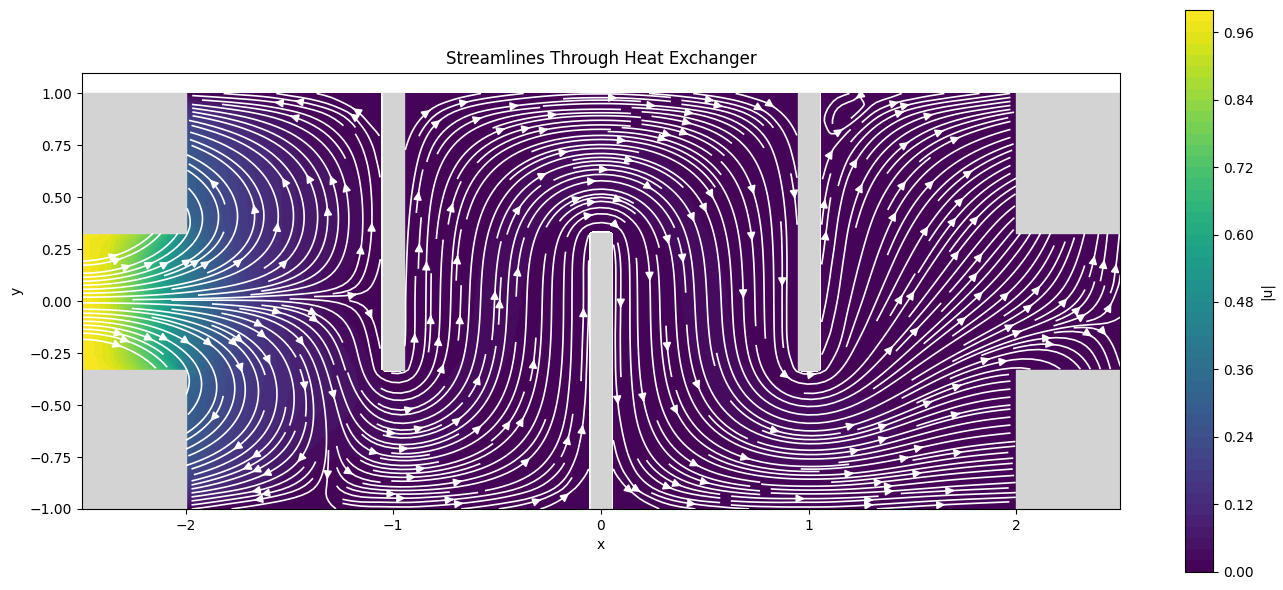

In [ ]:
plot_streamlines(p_fine, ux, uy)